In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("iris_data.csv",header=None)

In [3]:
df.shape

(150, 5)

In [4]:
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df.isna().sum()

0    0
1    0
2    0
3    0
4    0
dtype: int64

In [6]:
df.replace(['?',' ',' nil','na','-'],np.nan,inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
 4   4       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [9]:
x.shape

(150, 4)

In [10]:
y.shape

(150,)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder


In [12]:
encoder=LabelEncoder()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25, random_state=33,stratify=y)

In [13]:
y_train

53     Iris-versicolor
110     Iris-virginica
39         Iris-setosa
37         Iris-setosa
141     Iris-virginica
            ...       
20         Iris-setosa
10         Iris-setosa
42         Iris-setosa
41         Iris-setosa
5          Iris-setosa
Name: 4, Length: 112, dtype: object

In [14]:
y_train_encoded=encoder.fit_transform(y_train.values.reshape(-1,1))
y_test_encoded=encoder.transform(y_test.values.reshape(-1,1))

d:\MCAEnv\AribaVenv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\MCAEnv\AribaVenv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [15]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [16]:
import torch

In [17]:
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test_encoded,dtype=torch.long)
y_train_tensor=torch.tensor(y_train_encoded,dtype=torch.long)

In [18]:
x_train_tensor.shape, x_test_tensor.shape, y_test_tensor.shape, y_train_tensor.shape

(torch.Size([112, 4]),
 torch.Size([38, 4]),
 torch.Size([38]),
 torch.Size([112]))

In [19]:
from torch import nn

In [20]:
class IrisClassifier(nn.Module):
        def __init__(self):
                super(IrisClassifier, self).__init__()
                self.linear1=nn.Linear(4,8)
                self.relu = nn.ReLU()
                self.linear2 = nn.Linear(8, 3)
        
        def forward(self, x):
               return self.linear2(self.relu(self.linear1(x)))

In [21]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [22]:
losses=[]
for i in range(10000):
    optimizer.zero_grad()
    outputs = model(x_train_tensor)
    loss = loss_fn(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (i+1) % 100 == 0:
        print(f"Epoch {i + 1}: loss = {loss.item():.4f}")

Epoch 100: loss = 1.0415
Epoch 200: loss = 0.9327
Epoch 300: loss = 0.8279
Epoch 400: loss = 0.6964
Epoch 500: loss = 0.5542
Epoch 600: loss = 0.4479
Epoch 700: loss = 0.3801
Epoch 800: loss = 0.3352
Epoch 900: loss = 0.3030
Epoch 1000: loss = 0.2779
Epoch 1100: loss = 0.2574
Epoch 1200: loss = 0.2399
Epoch 1300: loss = 0.2247
Epoch 1400: loss = 0.2109
Epoch 1500: loss = 0.1982
Epoch 1600: loss = 0.1866
Epoch 1700: loss = 0.1760
Epoch 1800: loss = 0.1663
Epoch 1900: loss = 0.1576
Epoch 2000: loss = 0.1496
Epoch 2100: loss = 0.1423
Epoch 2200: loss = 0.1357
Epoch 2300: loss = 0.1296
Epoch 2400: loss = 0.1241
Epoch 2500: loss = 0.1191
Epoch 2600: loss = 0.1146
Epoch 2700: loss = 0.1104
Epoch 2800: loss = 0.1066
Epoch 2900: loss = 0.1031
Epoch 3000: loss = 0.0998
Epoch 3100: loss = 0.0968
Epoch 3200: loss = 0.0941
Epoch 3300: loss = 0.0915
Epoch 3400: loss = 0.0891
Epoch 3500: loss = 0.0869
Epoch 3600: loss = 0.0848
Epoch 3700: loss = 0.0829
Epoch 3800: loss = 0.0811
Epoch 3900: loss = 0.

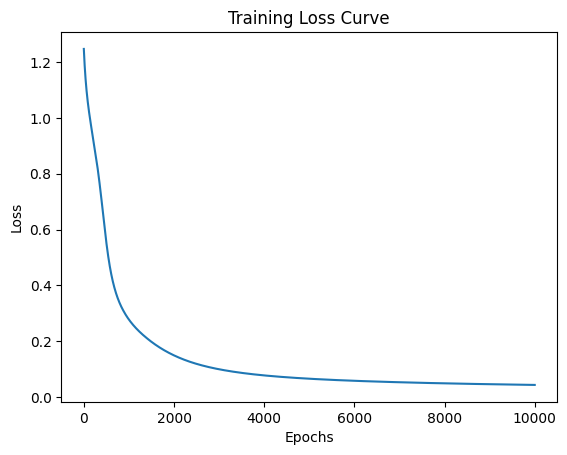

In [23]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [24]:
with torch.no_grad():
    y_pred=model(x_test_tensor)
    y_pred_classes=torch.argmax(y_pred,dim=1)

In [25]:
y_pred_np=y_pred_classes.numpy()
y_test_np=y_test_tensor.numpy()

In [31]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.metrics import precision_score, recall_score,f1_score
accuracy=accuracy_score(y_test_np,y_pred_np)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9737


In [33]:
precision = precision_score(y_test_np , y_pred_np, average='micro')
recall = recall_score(y_test_np , y_pred_np, average='micro')
f1 = f1_score(y_test_np, y_pred_np, average='micro')
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")
cm=confusion_matrix(y_test_np,y_pred_np)
print(cm)

Precision: 0.9736842105263158
Recall: 0.9736842105263158
F1 Score: <function f1_score at 0x00000246AC59CC20>
[[13  0  0]
 [ 0 12  1]
 [ 0  0 12]]


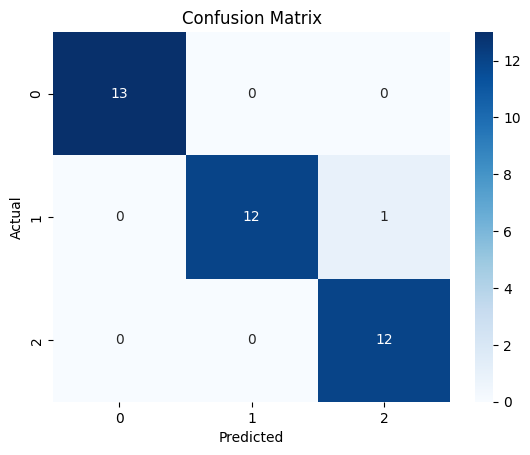

In [28]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
print(classification_report(y_pred_np,y_test_np))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.92      1.00      0.96        12
           2       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [35]:
from sklearn.preprocessing import label_binarize

In [ ]:
y_test_bin = label_binarize(y_test_np , classes=[0,1,2])

In [40]:
y_test_bin

array([[0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1]])

In [47]:
model.eval()

with torch.no_grad():
    y_scores = torch.softmax(model(x_test_tensor), dim=1).numpy()
print(y_scores)

[[7.7557494e-04 9.9886227e-01 3.6218730e-04]
 [1.0216329e-04 1.6369808e-02 9.8352802e-01]
 [1.0038534e-06 2.5736075e-04 9.9974161e-01]
 [9.9995697e-01 4.2352953e-05 6.8969354e-07]
 [7.9060846e-04 1.5507697e-01 8.4413242e-01]
 [4.7481308e-06 1.3306338e-04 9.9986219e-01]
 [5.3758518e-04 9.9870098e-01 7.6150562e-04]
 [9.9961132e-01 3.8779358e-04 9.5454266e-07]
 [5.1220477e-04 9.9835759e-01 1.1301965e-03]
 [2.8948843e-02 9.7074485e-01 3.0626243e-04]
 [9.9485046e-01 5.1425262e-03 7.0002166e-06]
 [9.9884665e-01 1.1520168e-03 1.3666381e-06]
 [2.8477882e-05 9.3419163e-04 9.9903738e-01]
 [3.1324489e-06 6.9208749e-05 9.9992764e-01]
 [9.9991930e-01 7.9230427e-05 1.4529118e-06]
 [9.9967360e-01 3.2491019e-04 1.5042425e-06]
 [9.9979192e-01 2.0712236e-04 9.7971463e-07]
 [3.0980646e-03 9.9508625e-01 1.8156603e-03]
 [1.8914752e-05 4.6735350e-03 9.9530751e-01]
 [8.4032147e-04 9.8648804e-01 1.2671589e-02]
 [2.3685510e-05 5.4789525e-03 9.9449736e-01]
 [2.6909547e-05 1.7836030e-03 9.9818951e-01]
 [9.991346

In [37]:
from sklearn.metrics import roc_curve , auc

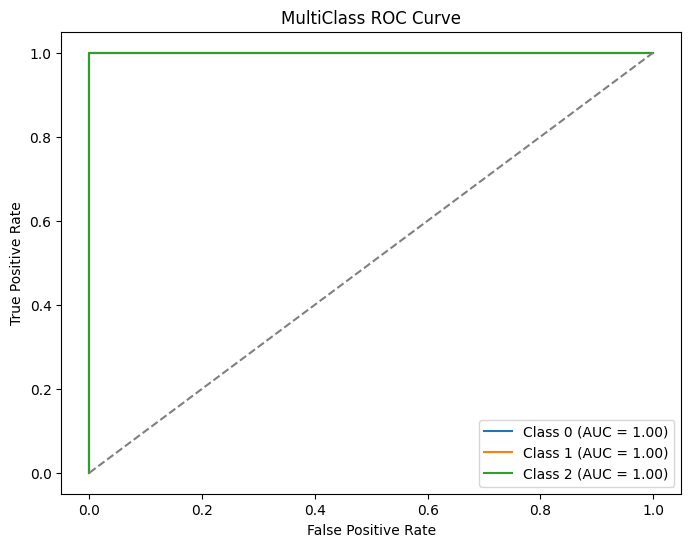

In [53]:
n_classes=y_test_bin.shape[1]
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr,_ =roc_curve(y_test_bin[:,i] , y_scores[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = { roc_auc:.2f})')
plt.plot([0,1] ,[0,1] , color ='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MultiClass ROC Curve')
plt.legend(loc = 'lower right')
